# Main code

In [ ]:
# ============================================================
# Notebook Notes:
# ============================================================
# This notebook implements the experiment for IntervalGP-VAE, evaluating its robustness 
# under degraded proxy conditions, including increased proxy noise, reduced proxy informativeness,
# proxy redundancy, and conditional independence violations induced by shared noise.
#
# Main goal:
#   Evaluate how IntervalGP-VAE behaves when proxy quality or
#   proxy assumptions are gradually degraded.
#
# The experiment studies three degradation settings:
#   D1: Proxy noise degradation
#   D2: Proxy informativeness / redundancy degradation
#   D3: Conditional independence violation through shared noise
#
# Experiment settings:
#   N_TRAIN = 1000
#   N_TEST = 300
#   LATENT_DIMS = [1, 2]
#   NUM_PROXIES = 8
#   RUN_SEEDS = [11, 22, 33]
#
# Degradation settings:
#   D1 proxy noise levels:
#      PROXY_NOISE_LEVELS = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0]
#
#   D2 proxy informativeness levels:
#      The number of informative proxies is gradually reduced from
#      all proxies to fewer informative proxies.
#
#      Non-informative proxies are either:
#         pure noise, or
#         redundant copies of the first informative proxy.
#
#   D3 shared-noise levels:
#      SHARED_NOISE_LEVELS = [0.0, 0.2, 0.5, 1.0]
#
#      Shared noise is added across proxy variables to violate
#      conditional independence among proxies.
#
# Synthetic data-generating mechanism:
#   U ~ N(0, I_d)
#
#   Proxy variables are generated as:
#      Z_i = g_i(U) + independent noise + shared noise
#
#   Treatment assignment follows:
#      T ~ Bernoulli(sigmoid(0.8U_1 + 0.4U_2))
#
#   Outcome model:
#      Y = base(U) + T * tau(U) + noise
#
#   True ITE:
#      tau(U) = 0.8 + 0.3U_1 + 0.2U_2
#
#   For d = 1, the second latent component U_2 is treated as zero.
#
# Proxy function bank:
#   The proxy transformations include:
#      U_1
#      sin(U_1)
#      tanh(U_1)
#      U_1^2
#      exp(-0.5U_1^2)
#      cos(U_1)
#      U_2
#      sin(U_2)
#      tanh(U_2)
#      U_2^2
#      U_1 * U_2
#      sin(U_1 + U_2)
#
# Model configuration:
#   chosen_version = "u_aux"
#   hidden_dim = 64
#   causal_head_hidden_dim = 64
#
#   The model latent dimension is set equal to the generated latent
#   dimension so that both d = 1 and d = 2 settings are meaningful.
#
# GP configuration:
#   GP_LENGTHSCALE = 7
#   GP_VARIANCE = 2.0
#   GP_NOISE = 1e-4
#
# Training configuration:
#   BATCH_SIZE = 128
#   JOINT_EPOCHS = 200
#   HEAD_EPOCHS = 100
#   VAE_REFINE_EPOCHS = 50
#
# Optimizer:
#   AdamW is used with:
#      LR_JOINT = 1e-3
#      LR_HEAD = 1e-3
#      LR_VAE_REFINE = 1e-4
#      WEIGHT_DECAY = 1e-5
#
# Three-stage training framework:
#   Stage 1:
#      Jointly train the VAE and causal head.
#
#   Stage 2:
#      Freeze the VAE and train only the causal head.
#
#   Stage 3:
#      Freeze the causal head and refine the VAE.
#
# Training-time GP role:
#   The notebook uses local marginal IntervalGP regularization
#   during mini-batch training.
#
#   This avoids full Cholesky decomposition inside each mini-batch.
#
# Inference-time GP role:
#   The notebook uses full GP posterior conditioning for:
#      latent GP posterior smoothing
#      ITE-space GP posterior prediction
#
# ITE uncertainty:
#   ITE_CI = 0.90
#   Z_VALUE_90 = 1.6448536269514722
#   N_MC_ITE = 100
#
# GP reference control:
#   MAX_GP_POINTS = None
#
#   This means the full GP reference set is used.
#   For larger datasets, MAX_GP_POINTS can be set to a finite value,
#   such as 300.
#
# Evaluation metrics:
#   PEHE
#   ATE error
#   90% ITE interval coverage
#   ITE interval width
#   Interval score
#   Latent RMSE
#   Runtime
#
# Latent recovery diagnostic:
#   Learned latent representations are aligned to the true latent
#   variables using ridge regression before computing latent RMSE.
#
# Purpose:
#   This experiment tests the robustness of IntervalGP-VAE under
#   degraded proxy conditions. It examines whether ITE accuracy,
#   coverage, interval width, and latent recovery degrade gracefully
#   as proxy noise increases, proxy informativeness decreases, or
#   conditional independence among proxies is violated.
# ============================================================

[D1] latent_dim=1, sigma_z=0.05, seed=11
    PEHE=0.0209, ATE=0.0038, Coverage=0.9867, Width=0.1672, Latent RMSE=0.0368, Time=2.74s
[D1] latent_dim=1, sigma_z=0.05, seed=22
    PEHE=0.0206, ATE=0.0033, Coverage=0.9900, Width=0.1778, Latent RMSE=0.0401, Time=2.25s
[D1] latent_dim=1, sigma_z=0.05, seed=33
    PEHE=0.0219, ATE=0.0045, Coverage=0.9867, Width=0.1607, Latent RMSE=0.0399, Time=2.24s
[D1] latent_dim=1, sigma_z=0.1, seed=11
    PEHE=0.0251, ATE=0.0018, Coverage=0.9833, Width=0.1674, Latent RMSE=0.0562, Time=2.22s
[D1] latent_dim=1, sigma_z=0.1, seed=22
    PEHE=0.0255, ATE=0.0048, Coverage=0.9867, Width=0.1759, Latent RMSE=0.0600, Time=2.23s
[D1] latent_dim=1, sigma_z=0.1, seed=33
    PEHE=0.0279, ATE=0.0082, Coverage=0.9867, Width=0.1589, Latent RMSE=0.0633, Time=2.23s
[D1] latent_dim=1, sigma_z=0.2, seed=11
    PEHE=0.0339, ATE=0.0036, Coverage=0.9867, Width=0.1724, Latent RMSE=0.0983, Time=2.21s
[D1] latent_dim=1, sigma_z=0.2, seed=22
    PEHE=0.0389, ATE=0.0076, Coverage=0.

,experiment,degradation_value,latent_dim,num_proxies,proxy_noise_std,informative_count,redundancy_mode,shared_noise_std,seed,time,pehe,ate_error,coverage,interval_width,interval_score,latent_rmse,ate_true,ate_est
0,D1_proxy_noise,0.05,1,8,0.05,8,noise_only,0.0,11,2.744936,0.020894,0.003834,0.986667,0.167213,0.191690,0.036792,0.774349,0.770515
1,D1_proxy_noise,0.05,1,8,0.05,8,noise_only,0.0,22,2.249229,0.020644,0.003292,0.990000,0.177829,0.194447,0.040094,0.827609,0.824317
2,D1_proxy_noise,0.05,1,8,0.05,8,noise_only,0.0,33,2.237886,0.021850,0.004512,0.986667,0.160715,0.172006,0.039930,0.771426,0.775938
3,D1_proxy_noise,0.10,1,8,0.10,8,noise_only,0.0,11,2.219694,0.025084,0.001778,0.983333,0.167359,0.194828,0.056170,0.774349,0.772571
4,D1_proxy_noise,0.10,1,8,0.10,8,noise_only,0.0,22,2.229474,0.025511,0.004838,0.986667,0.175855,0.196035,0.059998,0.827609,0.822772


Summary saved to:
experiment_d_intervalgpvae_fullgp_consistent_outputs/experiment_d_intervalgpvae_fullgp_summary.csv


,experiment,latent_dim,degradation_value,pehe_mean,pehe_std,ate_error_mean,ate_error_std,coverage_mean,coverage_std,interval_width_mean,interval_width_std,interval_score_mean,interval_score_std,latent_rmse_mean,latent_rmse_std,time_mean,time_std
0,D1_proxy_noise,1,0.05,0.021130,0.000637,0.003879,0.000611,0.987778,0.001925,0.168586,0.008639,0.186048,0.012239,0.038938,0.001861,2.410684,0.289527
1,D1_proxy_noise,1,0.10,0.026172,0.001529,0.004924,0.003190,0.985556,0.001925,0.167371,0.008478,0.187187,0.014293,0.059809,0.003549,2.224905,0.004922
2,D1_proxy_noise,1,0.20,0.038537,0.004420,0.009793,0.007498,0.966667,0.021858,0.169920,0.009137,0.198502,0.014148,0.104988,0.006436,2.213924,0.007660
3,D1_proxy_noise,1,0.50,0.080034,0.012761,0.031815,0.024173,0.771111,0.122490,0.186884,0.011029,0.404252,0.105992,0.223279,0.014952,2.219160,0.009388
4,D1_proxy_noise,1,1.00,0.169863,0.030853,0.114689,0.036606,0.385556,0.096398,0.188831,0.019889,1.455028,0.473961,0.402787,0.032913,2.227216,0.001488
5,D1_proxy_noise,1,2.00,0.379938,0.041121,0.315714,0.044570,0.131111,0.069309,0.218657,0.038447,4.706093,1.010911,0.685186,0.045569,2.209689,0.005854
6,D1_proxy_noise,2,0.05,0.097574,0.029863,0.009896,0.012055,0.843333,0.093868,0.244163,0.002924,0.584802,0.223795,0.318956,0.299552,2.418882,0.011070
7,D1_proxy_noise,2,0.10,0.101589,0.029056,0.013774,0.015010,0.831111,0.095122,0.239372,0.004854,0.604926,0.237290,0.331626,0.290460,2.412261,0.010375
8,D1_proxy_noise,2,0.20,0.115201,0.029997,0.022249,0.020843,0.781111,0.120984,0.238681,0.004074,0.685302,0.279466,0.362052,0.264396,2.420220,0.019924
9,D1_proxy_noise,2,0.50,0.180481,0.046315,0.069275,0.037812,0.552222,0.164801,0.239572,0.023151,1.381139,0.709401,0.501439,0.206060,2.410633,0.008152


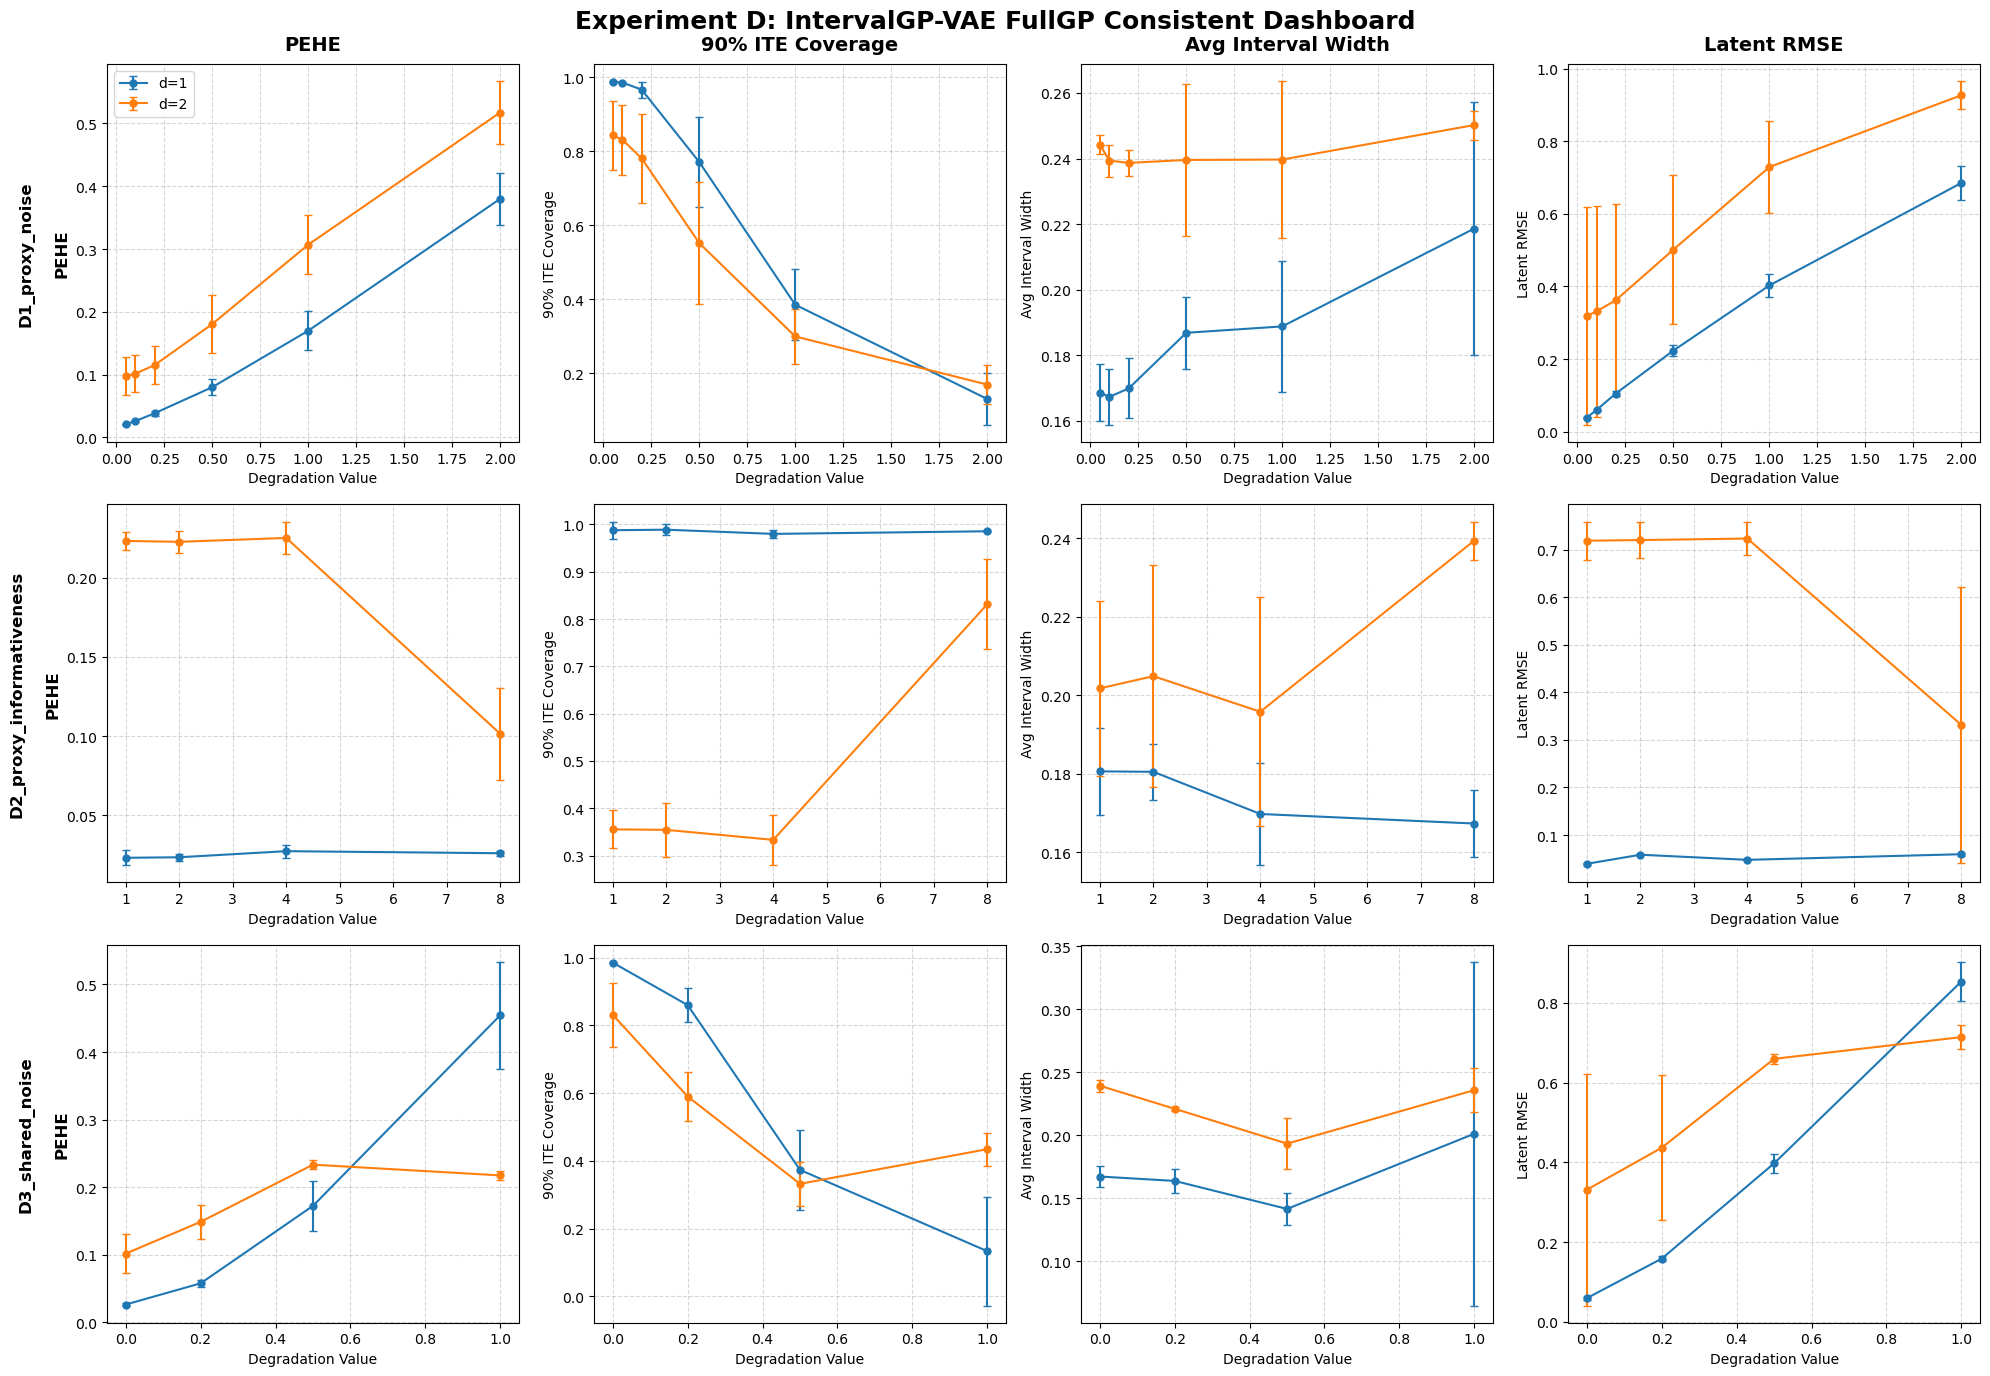

Saved consolidated dashboard plot to: experiment_d_intervalgpvae_fullgp_consistent_outputs/experiment_d_dashboard_results.png


,experiment,latent_dim,degradation_value,pehe_mean,ate_error_mean,coverage_mean,interval_width_mean,interval_score_mean,latent_rmse_mean,time_mean
0,D1_proxy_noise,1,0.05,0.0211,0.0039,0.9878,0.1686,0.1860,0.0389,2.4107
1,D1_proxy_noise,1,0.10,0.0262,0.0049,0.9856,0.1674,0.1872,0.0598,2.2249
2,D1_proxy_noise,1,0.20,0.0385,0.0098,0.9667,0.1699,0.1985,0.1050,2.2139
3,D1_proxy_noise,1,0.50,0.0800,0.0318,0.7711,0.1869,0.4043,0.2233,2.2192
4,D1_proxy_noise,1,1.00,0.1699,0.1147,0.3856,0.1888,1.4550,0.4028,2.2272
5,D1_proxy_noise,1,2.00,0.3799,0.3157,0.1311,0.2187,4.7061,0.6852,2.2097
6,D1_proxy_noise,2,0.05,0.0976,0.0099,0.8433,0.2442,0.5848,0.3190,2.4189
7,D1_proxy_noise,2,0.10,0.1016,0.0138,0.8311,0.2394,0.6049,0.3316,2.4123
8,D1_proxy_noise,2,0.20,0.1152,0.0222,0.7811,0.2387,0.6853,0.3621,2.4202
9,D1_proxy_noise,2,0.50,0.1805,0.0693,0.5522,0.2396,1.3811,0.5014,2.4106


LaTeX table saved to: experiment_d_intervalgpvae_fullgp_consistent_outputs/experiment_d_compact_summary_latex.txt


In [1]:
# ============================================================
# 0. Imports and basic settings
# ============================================================
import os
import gc
import time
import random
import itertools
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset, DataLoader
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")


# ============================================================
# 1. Global settings
# ============================================================

OUTPUT_DIR = "experiment_d_intervalgpvae_fullgp_consistent_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

GLOBAL_SEED = 42

# ------------------------------------------------------------
# Experiment D settings
# ------------------------------------------------------------
N_TRAIN = 1000
N_TEST = 300

LATENT_DIMS = [1, 2]
NUM_PROXIES = 8

PROXY_NOISE_LEVELS = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0]
SHARED_NOISE_LEVELS = [0.0, 0.2, 0.5, 1.0]

RUN_SEEDS = [11, 22, 33]

RUN_REDUNDANT_COPY_SETTING = True

# ------------------------------------------------------------
# IntervalGP-VAE settings aligned with the second implementation
# ------------------------------------------------------------
chosen_version = "u_aux"

INTERVALGPVAE_HIDDEN_DIM = 64
CAUSAL_HEAD_HIDDEN_DIM = 64

GP_LENGTHSCALE = 7
GP_VARIANCE = 2.0
GP_NOISE = 1e-4

BATCH_SIZE = 128
JOINT_EPOCHS = 200
HEAD_EPOCHS = 100
VAE_REFINE_EPOCHS = 50

LR_JOINT = 1e-3
LR_HEAD = 1e-3
LR_VAE_REFINE = 1e-4
WEIGHT_DECAY = 1e-5

ITE_CI = 0.90
Z_VALUE_90 = 1.6448536269514722

N_MC_ITE = 100

# Set to None to use full GP reference set.
# For larger data, set for example MAX_GP_POINTS = 300.
MAX_GP_POINTS = None


# ============================================================
# 2. Utility functions
# ============================================================

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def cleanup_memory():
    plt.close("all")
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def to_numpy_1d(x):
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    return np.asarray(x).reshape(-1)


def to_np(x):
    if torch.is_tensor(x):
        x = x.detach().cpu().numpy()
    return np.asarray(x)


def pehe_np(est_ite, true_ite):
    est_ite = to_numpy_1d(est_ite)
    true_ite = to_numpy_1d(true_ite)

    valid = np.isfinite(est_ite) & np.isfinite(true_ite)

    if valid.sum() == 0:
        return np.nan

    return float(np.sqrt(np.mean((est_ite[valid] - true_ite[valid]) ** 2)))


def ate_error_np(est_ite, true_ite):
    est_ite = to_numpy_1d(est_ite)
    true_ite = to_numpy_1d(true_ite)

    valid = np.isfinite(est_ite) & np.isfinite(true_ite)

    if valid.sum() == 0:
        return np.nan

    return float(abs(np.mean(est_ite[valid]) - np.mean(true_ite[valid])))


def interval_metrics_np(lower, upper, true_ite, alpha=0.10):
    lower = to_numpy_1d(lower)
    upper = to_numpy_1d(upper)
    true_ite = to_numpy_1d(true_ite)

    valid = (
        np.isfinite(lower)
        & np.isfinite(upper)
        & np.isfinite(true_ite)
    )

    if valid.sum() == 0:
        return np.nan, np.nan, np.nan

    lower = lower[valid]
    upper = upper[valid]
    true_ite = true_ite[valid]

    coverage = float(np.mean((lower <= true_ite) & (true_ite <= upper)))
    width = float(np.mean(upper - lower))

    below = true_ite < lower
    above = true_ite > upper

    score = (upper - lower).copy()
    score += (2.0 / alpha) * (lower - true_ite) * below
    score += (2.0 / alpha) * (true_ite - upper) * above
    score = float(np.mean(score))

    return coverage, width, score


def maybe_subsample_gp_reference(x, *ys, max_points=None, seed=0):
    n = x.shape[0]

    if max_points is None or n <= max_points:
        return (x, *ys)

    rng = np.random.default_rng(seed)
    idx = rng.choice(np.arange(n), size=max_points, replace=False)
    idx = np.sort(idx)

    idx_t = torch.tensor(idx, dtype=torch.long, device=x.device)

    out = [x[idx_t]]

    for y in ys:
        if torch.is_tensor(y):
            out.append(y[idx_t])
        else:
            out.append(np.asarray(y)[idx])

    return tuple(out)


set_seed(GLOBAL_SEED)


# %% [code]
# ============================================================
# 3. Synthetic data generation for Experiment D
# ============================================================

def generate_base_latent(n, latent_dim, seed):
    set_seed(seed)
    u = np.random.normal(0.0, 1.0, size=(n, latent_dim)).astype(np.float32)
    return u


def proxy_function_bank(u_tensor):
    """
    Return a bank of proxy transformations.

    Parameters
    ----------
    u_tensor:
        Tensor with shape (n, d).

    Returns
    -------
    funcs:
        List of tensors, each with shape (n, 1).
    """
    d = u_tensor.shape[1]
    u1 = u_tensor[:, [0]]

    if d >= 2:
        u2 = u_tensor[:, [1]]
    else:
        u2 = u1

    funcs = [
        u1,
        torch.sin(u1),
        torch.tanh(u1),
        u1 ** 2,
        torch.exp(-0.5 * u1 ** 2),
        torch.cos(u1),
        u2,
        torch.sin(u2),
        torch.tanh(u2),
        u2 ** 2,
        u1 * u2,
        torch.sin(u1 + u2),
    ]

    return funcs


def build_proxies(
    u_np,
    num_proxies=8,
    proxy_noise_std=0.1,
    informative_count=None,
    redundancy_mode="noise_only",
    shared_noise_std=0.0,
    seed=0,
):
    """
    Construct proxy variables.

    Settings
    --------
    informative_count:
        Number of informative proxies.

    redundancy_mode:
        "noise_only":
            Non-informative proxies are pure noise.

        "copy_first":
            Non-informative proxies copy the first informative proxy function,
            plus independent noise.

    shared_noise_std:
        Shared noise added to all proxies:
            Z_i = g_i(U) + eta_shared + eps_i.
    """
    set_seed(seed)

    n, latent_dim = u_np.shape
    u_tensor = torch.from_numpy(u_np).float()

    func_values = proxy_function_bank(u_tensor)

    if informative_count is None:
        informative_count = num_proxies

    informative_count = int(informative_count)
    informative_count = max(1, min(informative_count, num_proxies))

    z_clean_list = []

    for j in range(num_proxies):
        if j < informative_count:
            z_j = func_values[j % len(func_values)]
        else:
            if redundancy_mode == "copy_first":
                z_j = func_values[0]
            elif redundancy_mode == "noise_only":
                z_j = torch.zeros(n, 1)
            else:
                raise ValueError(f"Unknown redundancy_mode: {redundancy_mode}")

        z_clean_list.append(z_j)

    clean_z = torch.cat(z_clean_list, dim=1)

    independent_noise = torch.randn(n, num_proxies) * proxy_noise_std

    if shared_noise_std > 0:
        eta_shared = torch.randn(n, 1) * shared_noise_std
        shared_noise = eta_shared.repeat(1, num_proxies)
    else:
        shared_noise = torch.zeros(n, num_proxies)

    z = clean_z + independent_noise + shared_noise

    return z.float(), clean_z.float()


def treatment_assignment(u_np, seed=0):
    """
    Treatment assignment:
        T ~ Bernoulli(sigmoid(0.8 * U_1 + 0.4 * U_2)).
    """
    set_seed(seed)

    u1 = u_np[:, [0]]

    if u_np.shape[1] >= 2:
        u2 = u_np[:, [1]]
    else:
        u2 = 0.0

    logits = 0.8 * u1 + 0.4 * u2
    probs = 1.0 / (1.0 + np.exp(-logits))

    t = np.random.binomial(1, probs).astype(np.float32).reshape(-1)

    return t


def outcome_function(u_np, t_np, noise_std=0.1, seed=None):
    """
    Outcome model:
        Y = base(U) + T * tau(U) + eps.

    True ITE:
        tau(U) = 0.8 + 0.3 * U_1 + 0.2 * U_2.
    """
    if seed is not None:
        set_seed(seed)

    u1 = u_np[:, [0]]

    if u_np.shape[1] >= 2:
        u2 = u_np[:, [1]]
    else:
        u2 = np.zeros_like(u1)

    t_col = t_np.reshape(-1, 1)

    base = 0.5 * u1 + 0.2 * np.sin(u1) + 0.2 * np.cos(u2)
    tau = 0.8 + 0.3 * u1 + 0.2 * u2

    noise = np.random.normal(0.0, noise_std, size=base.shape).astype(np.float32)

    y = base + t_col * tau + noise

    return y.astype(np.float32).reshape(-1)


def true_ite_function(u_np):
    u1 = u_np[:, [0]]

    if u_np.shape[1] >= 2:
        u2 = u_np[:, [1]]
    else:
        u2 = np.zeros_like(u1)

    tau = 0.8 + 0.3 * u1 + 0.2 * u2

    return tau.astype(np.float32).reshape(-1)


def generate_experiment_d_data(
    n,
    latent_dim,
    num_proxies,
    proxy_noise_std,
    informative_count=None,
    redundancy_mode="noise_only",
    shared_noise_std=0.0,
    outcome_noise_std=0.1,
    seed=0,
):
    """
    Generate one synthetic dataset for Experiment D.
    """
    u_np = generate_base_latent(n, latent_dim, seed=seed)

    z, clean_z = build_proxies(
        u_np=u_np,
        num_proxies=num_proxies,
        proxy_noise_std=proxy_noise_std,
        informative_count=informative_count,
        redundancy_mode=redundancy_mode,
        shared_noise_std=shared_noise_std,
        seed=seed + 1000,
    )

    t_np = treatment_assignment(u_np, seed=seed + 2000)

    y_np = outcome_function(
        u_np,
        t_np,
        noise_std=outcome_noise_std,
        seed=seed + 3000,
    )

    true_ite_np = true_ite_function(u_np)

    return {
        "z": z.float(),
        "clean_z": clean_z.float(),
        "t": torch.from_numpy(t_np).float(),
        "y": torch.from_numpy(y_np).float(),
        "u": torch.from_numpy(u_np).float(),
        "true_ite": torch.from_numpy(true_ite_np).float(),
    }


def standardize_train_test(z_train, z_test):
    mean = z_train.mean(dim=0, keepdim=True)
    std = z_train.std(dim=0, keepdim=True).clamp_min(1e-6)

    z_train_std = (z_train - mean) / std
    z_test_std = (z_test - mean) / std

    return z_train_std, z_test_std, mean, std


# %% [code]
# ============================================================
# 4. IntervalGP-VAE FullGP model
#    Consistent with the second implementation
# ============================================================

class DoubleEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, use_auxiliary_latents=False):
        super().__init__()

        self.use_aux = use_auxiliary_latents

        self.fc1 = nn.Linear(input_dim, hidden_dim)

        self.mean_u = nn.Linear(hidden_dim, latent_dim)
        self.logvar_u = nn.Linear(hidden_dim, latent_dim)

        self.mean_eps = nn.Linear(hidden_dim, input_dim)
        self.logvar_eps = nn.Linear(hidden_dim, input_dim)

        if self.use_aux:
            self.mean_ua0 = nn.Linear(hidden_dim, latent_dim)
            self.logvar_ua0 = nn.Linear(hidden_dim, latent_dim)

            self.mean_ua1 = nn.Linear(hidden_dim, latent_dim)
            self.logvar_ua1 = nn.Linear(hidden_dim, latent_dim)

    def forward(self, z):
        h = F.relu(self.fc1(z))

        mu_u = self.mean_u(h)
        logvar_u = self.logvar_u(h)
        std_u = torch.exp(0.5 * logvar_u)

        mu_eps = self.mean_eps(h)
        logvar_eps = self.logvar_eps(h)
        std_eps = torch.exp(0.5 * logvar_eps)

        if self.use_aux:
            mu_ua0 = self.mean_ua0(h)
            logvar_ua0 = self.logvar_ua0(h)
            std_ua0 = torch.exp(0.5 * logvar_ua0)

            mu_ua1 = self.mean_ua1(h)
            logvar_ua1 = self.logvar_ua1(h)
            std_ua1 = torch.exp(0.5 * logvar_ua1)

            return (
                mu_u, std_u, logvar_u,
                mu_eps, std_eps, logvar_eps,
                mu_ua0, std_ua0, logvar_ua0,
                mu_ua1, std_ua1, logvar_ua1,
            )

        return mu_u, std_u, logvar_u, mu_eps, std_eps, logvar_eps


class AdditiveDecoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim, use_auxiliary_latents=False):
        super().__init__()

        self.use_aux = use_auxiliary_latents

        factor = 1 + (2 if use_auxiliary_latents else 0)

        self.fc1 = nn.Linear(latent_dim * factor, hidden_dim)
        self.out = nn.Linear(hidden_dim, output_dim)

    def forward(self, u, eps, ua0=None, ua1=None):
        if self.use_aux:
            x = torch.cat([u, ua0, ua1], dim=1)
        else:
            x = u

        h = F.relu(self.fc1(x))

        return self.out(h) + eps


class GPVAEwithNoise(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim,
        latent_dim,
        gp_lengthscale=GP_LENGTHSCALE,
        gp_variance=GP_VARIANCE,
        gp_noise=GP_NOISE,
        use_auxiliary_latents=False,
    ):
        super().__init__()

        self.use_aux = use_auxiliary_latents

        self.encoder = DoubleEncoder(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            latent_dim=latent_dim,
            use_auxiliary_latents=use_auxiliary_latents,
        )

        self.decoder = AdditiveDecoder(
            latent_dim=latent_dim,
            hidden_dim=hidden_dim,
            output_dim=input_dim,
            use_auxiliary_latents=use_auxiliary_latents,
        )

        self.gp_lengthscale = gp_lengthscale
        self.gp_variance = gp_variance
        self.gp_noise = gp_noise

    def reparameterize(self, mu, std):
        return mu + torch.randn_like(std) * std

    def local_interval_gp_regularizer(self, z, mu_u, std_u):
        """
        Local marginal IntervalGP regulariser used during mini-batch training.

        This matches the second implementation:
        - no full Cholesky inside mini-batch training,
        - uses local Gaussian marginal probability of the encoder-induced interval.
        """
        k_ii = self.gp_variance * torch.ones_like(mu_u)
        gp_std = torch.sqrt(k_ii + self.gp_noise)

        lower = mu_u - std_u
        upper = mu_u + std_u

        normal = torch.distributions.Normal(
            loc=torch.zeros_like(mu_u),
            scale=gp_std,
        )

        prob = normal.cdf(upper) - normal.cdf(lower)
        prob = torch.clamp(prob, min=1e-8)

        return -torch.sum(torch.log(prob))

    def get_latent_stats(self, z, var_name="u"):
        outputs = self.encoder(z)

        if var_name == "u":
            return outputs[0], outputs[1], outputs[2]

        if var_name == "eps":
            return outputs[3], outputs[4], outputs[5]

        if var_name == "ua0":
            if not self.use_aux:
                return None, None, None
            return outputs[6], outputs[7], outputs[8]

        if var_name == "ua1":
            if not self.use_aux:
                return None, None, None
            return outputs[9], outputs[10], outputs[11]

        raise ValueError(f"Invalid var_name: {var_name}")

    def sample_latent(self, z, var_name="u"):
        mu, std, _ = self.get_latent_stats(z, var_name=var_name)

        if mu is None:
            return None

        return self.reparameterize(mu, std)

    def forward(self, z):
        if self.use_aux:
            (
                mu_u, std_u, logvar_u,
                mu_eps, std_eps, logvar_eps,
                mu_ua0, std_ua0, logvar_ua0,
                mu_ua1, std_ua1, logvar_ua1,
            ) = self.encoder(z)

            u = self.reparameterize(mu_u, std_u)
            eps = self.reparameterize(mu_eps, std_eps)
            ua0 = self.reparameterize(mu_ua0, std_ua0)
            ua1 = self.reparameterize(mu_ua1, std_ua1)

            z_recon = self.decoder(u, eps, ua0=ua0, ua1=ua1)

        else:
            mu_u, std_u, logvar_u, mu_eps, std_eps, logvar_eps = self.encoder(z)

            u = self.reparameterize(mu_u, std_u)
            eps = self.reparameterize(mu_eps, std_eps)

            ua0 = None
            ua1 = None

            z_recon = self.decoder(u, eps)

        recon_loss = F.mse_loss(z_recon, z, reduction="sum")

        # Consistent with second code:
        # KL on u is down-weighted by 0.001.
        kl_u = -0.001 * torch.sum(
            1 + logvar_u - mu_u.pow(2) - logvar_u.exp()
        )

        kl_eps = -0.5 * torch.sum(
            1 + logvar_eps - mu_eps.pow(2) - logvar_eps.exp()
        )

        gp_interval_reg = self.local_interval_gp_regularizer(
            z=z,
            mu_u=mu_u,
            std_u=std_u,
        )

        std_penalty = torch.sum(std_u ** 2)

        total_loss = (
            recon_loss
            + kl_u
            + kl_eps
            + gp_interval_reg
            + 10.0 * std_penalty
        )

        info = {
            "recon_loss": recon_loss.item(),
            "kl_u": kl_u.item(),
            "kl_eps": kl_eps.item(),
            "gp_interval_reg": gp_interval_reg.item(),
            "std_penalty": std_penalty.item(),
            "u": u,
            "eps": eps,
            "ua0": ua0,
            "ua1": ua1,
            "mu_u": mu_u,
            "std_u": std_u,
            "z_recon": z_recon,
        }

        if self.use_aux:
            kl_ua0 = -0.5 * torch.sum(
                1 + logvar_ua0 - mu_ua0.pow(2) - logvar_ua0.exp()
            )

            kl_ua1 = -0.5 * torch.sum(
                1 + logvar_ua1 - mu_ua1.pow(2) - logvar_ua1.exp()
            )

            total_loss = total_loss + kl_ua0 + kl_ua1

            info["kl_ua0"] = kl_ua0.item()
            info["kl_ua1"] = kl_ua1.item()

        return total_loss, info


class FlexibleCausalHead(nn.Module):
    def __init__(
        self,
        latent_dim_u,
        hidden_dim=CAUSAL_HEAD_HIDDEN_DIM,
        z_y_dim=None,
        use_auxiliary_latents=False,
    ):
        super().__init__()

        self.use_aux = use_auxiliary_latents
        self.z_y_dim = z_y_dim

        input_dim = latent_dim_u + 1

        if z_y_dim is not None:
            input_dim += z_y_dim

        if use_auxiliary_latents:
            input_dim += latent_dim_u

        self.fc = nn.Linear(input_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, u, t, z_y=None, ua1=None):
        t = t.view(-1, 1)

        parts = [u, t]

        if self.z_y_dim is not None:
            if z_y is None:
                raise ValueError("Expected z_y input but got None.")
            parts.append(z_y)

        if self.use_aux:
            if ua1 is None:
                raise ValueError("Expected ua1 input but got None.")
            parts.append(ua1)

        x = torch.cat(parts, dim=1)
        h = F.relu(self.fc(x))

        return self.out(h)


def make_z_y(model, z):
    if model.causal_head.z_y_dim == z.shape[1]:
        return z

    if model.causal_head.z_y_dim:
        return z[:, z.shape[1] // 2:]

    return None


class CausalGPVAEwithNoise(nn.Module):
    def __init__(
        self,
        input_dim,
        hidden_dim,
        latent_dim,
        z_y_dim=None,
        use_auxiliary_latents=False,
        gp_lengthscale=GP_LENGTHSCALE,
        gp_variance=GP_VARIANCE,
        gp_noise=GP_NOISE,
    ):
        super().__init__()

        self.z_y_dim = z_y_dim
        self.use_aux = use_auxiliary_latents

        self.vae = GPVAEwithNoise(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            latent_dim=latent_dim,
            gp_lengthscale=gp_lengthscale,
            gp_variance=gp_variance,
            gp_noise=gp_noise,
            use_auxiliary_latents=use_auxiliary_latents,
        )

        self.causal_head = FlexibleCausalHead(
            latent_dim_u=latent_dim,
            hidden_dim=CAUSAL_HEAD_HIDDEN_DIM,
            z_y_dim=z_y_dim,
            use_auxiliary_latents=use_auxiliary_latents,
        )

    def forward(self, z, t, y):
        loss_vae, vae_info = self.vae(z)

        u = vae_info["u"]
        ua1 = vae_info["ua1"] if self.use_aux else None

        z_y = make_z_y(self, z)

        y_pred = self.causal_head(
            u,
            t,
            z_y=z_y,
            ua1=ua1,
        )

        causal_loss = F.mse_loss(
            y_pred,
            y.unsqueeze(-1),
            reduction="sum",
        )

        total_loss = loss_vae + causal_loss

        return total_loss, {
            **vae_info,
            "y_pred": y_pred,
            "causal_loss": causal_loss.item(),
        }


# %% [code]
# ============================================================
# 5. Full GP posterior and ITE-space IntervalGP functions
# ============================================================

def rbf_kernel(x1, x2=None, lengthscale=1.0, variance=1.0):
    if x2 is None:
        x2 = x1

    if x1.ndim == 1:
        x1 = x1.view(-1, 1)

    if x2.ndim == 1:
        x2 = x2.view(-1, 1)

    dists = torch.cdist(x1, x2).pow(2)

    return variance * torch.exp(-0.5 * dists / (lengthscale ** 2))


def full_gp_posterior_point(
    x_train,
    y_train,
    x_test,
    lengthscale=GP_LENGTHSCALE,
    variance=GP_VARIANCE,
    noise=GP_NOISE,
    jitter=1e-5,
):
    x_train = x_train.float()
    x_test = x_test.float()
    y_train = y_train.float().view(-1, 1)

    n_train = x_train.shape[0]
    n_test = x_test.shape[0]

    K = rbf_kernel(
        x_train,
        x_train,
        lengthscale=lengthscale,
        variance=variance,
    )

    K = K + noise * torch.eye(n_train, device=x_train.device)

    K_s = rbf_kernel(
        x_train,
        x_test,
        lengthscale=lengthscale,
        variance=variance,
    )

    K_ss = rbf_kernel(
        x_test,
        x_test,
        lengthscale=lengthscale,
        variance=variance,
    )

    K_ss = K_ss + jitter * torch.eye(n_test, device=x_test.device)

    current_jitter = jitter

    for _ in range(8):
        try:
            L = torch.linalg.cholesky(
                K + current_jitter * torch.eye(n_train, device=x_train.device)
            )
            break
        except RuntimeError:
            current_jitter *= 10
    else:
        raise RuntimeError("Cholesky failed in full_gp_posterior_point.")

    alpha = torch.cholesky_solve(y_train, L)

    posterior_mean = K_s.t() @ alpha

    v = torch.cholesky_solve(K_s, L)
    posterior_cov = K_ss - K_s.t() @ v
    posterior_cov = 0.5 * (posterior_cov + posterior_cov.t())

    return posterior_mean.squeeze(-1), posterior_cov


def full_gp_posterior_heteroscedastic(
    x_train,
    y_train,
    x_test,
    noise_var_train,
    lengthscale=GP_LENGTHSCALE,
    variance=GP_VARIANCE,
    min_noise=GP_NOISE,
    jitter=1e-5,
):
    x_train = x_train.float()
    x_test = x_test.float()
    y_train = y_train.float().view(-1, 1)

    noise_var_train = noise_var_train.float().view(-1)
    noise_var_train = torch.clamp(noise_var_train, min=min_noise)

    n_train = x_train.shape[0]
    n_test = x_test.shape[0]

    K = rbf_kernel(
        x_train,
        x_train,
        lengthscale=lengthscale,
        variance=variance,
    )

    K = K + torch.diag(noise_var_train)

    K_s = rbf_kernel(
        x_train,
        x_test,
        lengthscale=lengthscale,
        variance=variance,
    )

    K_ss = rbf_kernel(
        x_test,
        x_test,
        lengthscale=lengthscale,
        variance=variance,
    )

    K_ss = K_ss + jitter * torch.eye(n_test, device=x_test.device)

    current_jitter = jitter

    for _ in range(8):
        try:
            L = torch.linalg.cholesky(
                K + current_jitter * torch.eye(n_train, device=x_train.device)
            )
            break
        except RuntimeError:
            current_jitter *= 10
    else:
        raise RuntimeError("Cholesky failed in full_gp_posterior_heteroscedastic.")

    alpha = torch.cholesky_solve(y_train, L)
    posterior_mean = K_s.t() @ alpha

    v = torch.cholesky_solve(K_s, L)
    posterior_cov = K_ss - K_s.t() @ v
    posterior_cov = 0.5 * (posterior_cov + posterior_cov.t())

    return posterior_mean.squeeze(-1), posterior_cov


def latent_gp_posterior_smoothing(
    z_train,
    mu_u_train,
    z_test,
    lengthscale=GP_LENGTHSCALE,
    variance=GP_VARIANCE,
    noise=GP_NOISE,
):
    if mu_u_train.ndim == 1:
        mu_u_train = mu_u_train.view(-1, 1)

    latent_dim = mu_u_train.shape[1]

    means = []
    vars_diag = []

    for r in range(latent_dim):
        mean_r, cov_r = full_gp_posterior_point(
            x_train=z_train,
            y_train=mu_u_train[:, r],
            x_test=z_test,
            lengthscale=lengthscale,
            variance=variance,
            noise=noise,
        )

        var_r = torch.diag(cov_r).clamp_min(1e-8)

        means.append(mean_r)
        vars_diag.append(var_r)

    mean = torch.stack(means, dim=1)
    std = torch.sqrt(torch.stack(vars_diag, dim=1))

    return mean, std


def sample_ite_from_encoder(
    model,
    z,
    n_samples=N_MC_ITE,
):
    model.eval()

    with torch.no_grad():
        mu_u, std_u, _ = model.vae.get_latent_stats(z, var_name="u")

        N, d_u = mu_u.shape
        device = z.device

        z_y = make_z_y(model, z)

        mu_ua1, std_ua1, _ = model.vae.get_latent_stats(z, var_name="ua1")
        has_ua1 = (mu_ua1 is not None) and (std_ua1 is not None)

        eps_u = torch.randn(n_samples, N, d_u, device=device)
        u_samples = mu_u.unsqueeze(0) + eps_u * std_u.unsqueeze(0)
        U = u_samples.reshape(-1, d_u)

        if has_ua1:
            d_ua = mu_ua1.shape[1]
            eps_ua1 = torch.randn(n_samples, N, d_ua, device=device)
            ua1_samples = mu_ua1.unsqueeze(0) + eps_ua1 * std_ua1.unsqueeze(0)
            UA1 = ua1_samples.reshape(-1, d_ua)
        else:
            UA1 = None

        if z_y is not None:
            ZY = (
                z_y.unsqueeze(0)
                .expand(n_samples, -1, -1)
                .reshape(-1, z_y.shape[1])
            )
        else:
            ZY = None

        t0 = torch.zeros(U.shape[0], device=device)
        t1 = torch.ones(U.shape[0], device=device)

        y0 = model.causal_head(U, t0, z_y=ZY, ua1=UA1).squeeze(-1)
        y1 = model.causal_head(U, t1, z_y=ZY, ua1=UA1).squeeze(-1)

        ite_samples = (y1 - y0).view(n_samples, N)

        lower_q = (1.0 - ITE_CI) / 2.0
        upper_q = 1.0 - lower_q

        ite_mean = ite_samples.mean(dim=0)
        ite_std = ite_samples.std(dim=0)
        ite_lower = ite_samples.quantile(lower_q, dim=0)
        ite_upper = ite_samples.quantile(upper_q, dim=0)

        return ite_samples, ite_mean, ite_std, ite_lower, ite_upper


def ite_space_intervalgp_head(
    model,
    z_train,
    z_test,
    n_samples=N_MC_ITE,
    lengthscale=GP_LENGTHSCALE,
    variance=GP_VARIANCE,
    min_noise=GP_NOISE,
):
    model.eval()

    with torch.no_grad():
        _, ite_mean_train, ite_std_train, ite_lower_train, ite_upper_train = (
            sample_ite_from_encoder(
                model=model,
                z=z_train,
                n_samples=n_samples,
            )
        )

        mu_u_train, _, _ = model.vae.get_latent_stats(z_train, var_name="u")
        mu_u_test, _, _ = model.vae.get_latent_stats(z_test, var_name="u")

        u_test_smooth, u_test_smooth_std = latent_gp_posterior_smoothing(
            z_train=z_train,
            mu_u_train=mu_u_train,
            z_test=z_test,
            lengthscale=lengthscale,
            variance=variance,
            noise=min_noise,
        )

        u_train_smooth = mu_u_train.detach()

        (
            u_train_gp,
            ite_lower_train_gp,
            ite_upper_train_gp,
            ite_mean_train_gp,
            ite_std_train_gp,
        ) = maybe_subsample_gp_reference(
            u_train_smooth,
            ite_lower_train.detach(),
            ite_upper_train.detach(),
            ite_mean_train.detach(),
            ite_std_train.detach(),
            max_points=MAX_GP_POINTS,
            seed=123,
        )

        noise_var_lower = ite_std_train_gp.pow(2) + min_noise
        noise_var_upper = ite_std_train_gp.pow(2) + min_noise
        noise_var_mean = ite_std_train_gp.pow(2) + min_noise

        gp_lower_mean, gp_lower_cov = full_gp_posterior_heteroscedastic(
            x_train=u_train_gp,
            y_train=ite_lower_train_gp,
            x_test=u_test_smooth,
            noise_var_train=noise_var_lower,
            lengthscale=lengthscale,
            variance=variance,
            min_noise=min_noise,
        )

        gp_upper_mean, gp_upper_cov = full_gp_posterior_heteroscedastic(
            x_train=u_train_gp,
            y_train=ite_upper_train_gp,
            x_test=u_test_smooth,
            noise_var_train=noise_var_upper,
            lengthscale=lengthscale,
            variance=variance,
            min_noise=min_noise,
        )

        gp_ite_mean, gp_ite_cov = full_gp_posterior_heteroscedastic(
            x_train=u_train_gp,
            y_train=ite_mean_train_gp,
            x_test=u_test_smooth,
            noise_var_train=noise_var_mean,
            lengthscale=lengthscale,
            variance=variance,
            min_noise=min_noise,
        )

        gp_lower_std = torch.sqrt(torch.diag(gp_lower_cov).clamp_min(1e-8))
        gp_upper_std = torch.sqrt(torch.diag(gp_upper_cov).clamp_min(1e-8))

        raw_lower = torch.minimum(gp_lower_mean, gp_upper_mean)
        raw_upper = torch.maximum(gp_lower_mean, gp_upper_mean)

        ite_lower_test = raw_lower - Z_VALUE_90 * gp_lower_std
        ite_upper_test = raw_upper + Z_VALUE_90 * gp_upper_std

        return {
            "ite_mean_test": gp_ite_mean,
            "ite_lower_test": ite_lower_test,
            "ite_upper_test": ite_upper_test,
            "u_test_smooth": u_test_smooth,
            "u_test_smooth_std": u_test_smooth_std,
            "u_test_raw": mu_u_test,
        }


# %% [code]
# ============================================================
# 6. Training wrapper aligned with the second implementation
# ============================================================

def train_intervalgpvae_fullgp(
    z_train_all,
    t_train_all,
    y_train_all,
    model_latent_dim,
    iteration_id=0,
    device=DEVICE,
):
    """
    Train IntervalGP-VAE using the same framework as the second code.

    Notes
    -----
    - In the second implementation, INTERVALGPVAE_LATENT_DIM is fixed to 1.
    - Here, model_latent_dim is set equal to the generated latent dimension
      so that Experiment D can still evaluate latent_dim = 1 and latent_dim = 2.
    - Other parameters and framework are kept consistent with the second code.
    """
    set_seed(GLOBAL_SEED + iteration_id)

    use_aux = chosen_version == "u_aux"

    if chosen_version == "z_to_y":
        z_y_dim = z_train_all.shape[1]
    elif chosen_version == "split_z_to_t_and_y":
        z_y_dim = z_train_all.shape[1] // 2
    else:
        z_y_dim = None

    loader = DataLoader(
        TensorDataset(z_train_all, t_train_all, y_train_all),
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=False,
    )

    model = CausalGPVAEwithNoise(
        input_dim=z_train_all.shape[1],
        hidden_dim=INTERVALGPVAE_HIDDEN_DIM,
        latent_dim=model_latent_dim,
        z_y_dim=z_y_dim,
        use_auxiliary_latents=use_aux,
        gp_lengthscale=GP_LENGTHSCALE,
        gp_variance=GP_VARIANCE,
        gp_noise=GP_NOISE,
    ).to(device)

    # --------------------------------------------------------
    # Stage 1: joint training of VAE and causal head
    # --------------------------------------------------------
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR_JOINT,
        weight_decay=WEIGHT_DECAY,
    )

    for epoch in range(JOINT_EPOCHS):
        model.train()

        for z_batch, t_batch, y_batch in loader:
            z_batch = z_batch.to(device)
            t_batch = t_batch.to(device)
            y_batch = y_batch.to(device)

            loss, _ = model(z_batch, t_batch, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # --------------------------------------------------------
    # Stage 2: freeze VAE and tune causal head
    # --------------------------------------------------------
    for param in model.vae.parameters():
        param.requires_grad = False

    for param in model.causal_head.parameters():
        param.requires_grad = True

    causal_optimizer = torch.optim.AdamW(
        model.causal_head.parameters(),
        lr=LR_HEAD,
        weight_decay=WEIGHT_DECAY,
    )

    for epoch in range(HEAD_EPOCHS):
        model.train()

        for z_batch, t_batch, y_batch in loader:
            z_batch = z_batch.to(device)
            t_batch = t_batch.to(device)
            y_batch = y_batch.to(device)

            with torch.no_grad():
                mu_u = model.vae.get_latent_stats(
                    z_batch,
                    var_name="u",
                )[0]

                if model.use_aux:
                    mu_ua1, std_ua1, _ = model.vae.get_latent_stats(
                        z_batch,
                        var_name="ua1",
                    )

                    ua1_batch = model.vae.reparameterize(
                        mu_ua1,
                        std_ua1,
                    )
                else:
                    ua1_batch = None

            z_y_batch = make_z_y(model, z_batch)

            y_pred = model.causal_head(
                mu_u.detach(),
                t_batch,
                z_y=z_y_batch,
                ua1=ua1_batch.detach() if ua1_batch is not None else None,
            )

            causal_loss = F.mse_loss(
                y_pred,
                y_batch.unsqueeze(-1),
            )

            causal_optimizer.zero_grad()
            causal_loss.backward()
            causal_optimizer.step()

    # --------------------------------------------------------
    # Stage 3: freeze causal head and refine VAE
    # --------------------------------------------------------
    for param in model.causal_head.parameters():
        param.requires_grad = False

    for param in model.vae.parameters():
        param.requires_grad = True

    vae_optimizer = torch.optim.AdamW(
        model.vae.parameters(),
        lr=LR_VAE_REFINE,
        weight_decay=WEIGHT_DECAY,
    )

    for epoch in range(VAE_REFINE_EPOCHS):
        model.train()

        for z_batch, t_batch, y_batch in loader:
            z_batch = z_batch.to(device)
            t_batch = t_batch.to(device)
            y_batch = y_batch.to(device)

            z_y_batch = make_z_y(model, z_batch)

            loss_vae, vae_info = model.vae(z_batch)

            ua1_batch = (
                model.vae.sample_latent(z_batch, var_name="ua1")
                if model.use_aux
                else None
            )

            y_pred = model.causal_head(
                vae_info["u"],
                t_batch,
                z_y=z_y_batch,
                ua1=ua1_batch,
            )

            causal_loss = F.mse_loss(
                y_pred,
                y_batch.unsqueeze(-1),
                reduction="sum",
            )

            total_loss = loss_vae + causal_loss

            vae_optimizer.zero_grad()
            total_loss.backward()
            vae_optimizer.step()

    for param in model.parameters():
        param.requires_grad = True

    return model


# %% [code]
# ============================================================
# 7. Evaluation functions
# ============================================================

def align_latent_linear(mu_u_np, true_u_np):
    """
    Align learnt latent representation to true U using ridge regression.

    This is only for latent recovery evaluation because latent representations
    are identifiable up to transformations.
    """
    reg = Ridge(alpha=1e-3)
    reg.fit(mu_u_np, true_u_np)
    aligned = reg.predict(mu_u_np)

    return aligned


def evaluate_intervalgpvae_fullgp(
    model,
    z_train,
    z_test,
    true_u_test,
    true_ite_test,
):
    model.eval()

    z_train = z_train.to(DEVICE)
    z_test = z_test.to(DEVICE)

    with torch.no_grad():
        mu_u_test_raw, _, _ = model.vae.get_latent_stats(z_test, var_name="u")

    mu_u_np = mu_u_test_raw.detach().cpu().numpy()
    true_u_np = true_u_test.detach().cpu().numpy()

    aligned_u = align_latent_linear(mu_u_np, true_u_np)
    latent_rmse = np.sqrt(mean_squared_error(true_u_np, aligned_u))

    intervalgp_results = ite_space_intervalgp_head(
        model=model,
        z_train=z_train,
        z_test=z_test,
        n_samples=N_MC_ITE,
        lengthscale=GP_LENGTHSCALE,
        variance=GP_VARIANCE,
        min_noise=GP_NOISE,
    )

    ite_mean = to_numpy_1d(intervalgp_results["ite_mean_test"])
    ite_lower = to_numpy_1d(intervalgp_results["ite_lower_test"])
    ite_upper = to_numpy_1d(intervalgp_results["ite_upper_test"])

    true_ite_np = to_numpy_1d(true_ite_test)

    pehe = pehe_np(ite_mean, true_ite_np)
    ate_error = ate_error_np(ite_mean, true_ite_np)

    coverage, width, interval_score = interval_metrics_np(
        lower=ite_lower,
        upper=ite_upper,
        true_ite=true_ite_np,
        alpha=1.0 - ITE_CI,
    )

    return {
        "pehe": pehe,
        "ate_error": ate_error,
        "coverage": coverage,
        "interval_width": width,
        "interval_score": interval_score,
        "latent_rmse": float(latent_rmse),
        "ate_true": float(np.mean(true_ite_np)),
        "ate_est": float(np.mean(ite_mean)),
    }


# %% [code]
# ============================================================
# 8. Single-run wrapper
# ============================================================

def run_single_setting(
    experiment_name,
    degradation_value,
    latent_dim,
    num_proxies,
    proxy_noise_std,
    informative_count,
    redundancy_mode,
    shared_noise_std,
    seed,
):
    start_time = time.time()

    data_train = generate_experiment_d_data(
        n=N_TRAIN,
        latent_dim=latent_dim,
        num_proxies=num_proxies,
        proxy_noise_std=proxy_noise_std,
        informative_count=informative_count,
        redundancy_mode=redundancy_mode,
        shared_noise_std=shared_noise_std,
        outcome_noise_std=0.1,
        seed=seed,
    )

    data_test = generate_experiment_d_data(
        n=N_TEST,
        latent_dim=latent_dim,
        num_proxies=num_proxies,
        proxy_noise_std=proxy_noise_std,
        informative_count=informative_count,
        redundancy_mode=redundancy_mode,
        shared_noise_std=shared_noise_std,
        outcome_noise_std=0.1,
        seed=seed + 50000,
    )

    z_train = data_train["z"]
    z_test = data_test["z"]

    z_train_std, z_test_std, z_mean, z_std = standardize_train_test(
        z_train,
        z_test,
    )

    z_train_std = z_train_std.to(DEVICE)
    z_test_std = z_test_std.to(DEVICE)

    t_train = data_train["t"].to(DEVICE)
    y_train = data_train["y"].to(DEVICE)

    # Important:
    # In the second code, latent_dim is fixed as INTERVALGPVAE_LATENT_DIM = 1.
    # For Experiment D, we allow model_latent_dim = latent_dim to keep the
    # d=1 and d=2 settings meaningful.
    model = train_intervalgpvae_fullgp(
        z_train_all=z_train_std,
        t_train_all=t_train,
        y_train_all=y_train,
        model_latent_dim=latent_dim,
        iteration_id=seed + latent_dim * 100,
        device=DEVICE,
    )

    metrics = evaluate_intervalgpvae_fullgp(
        model=model,
        z_train=z_train_std,
        z_test=z_test_std,
        true_u_test=data_test["u"],
        true_ite_test=data_test["true_ite"],
    )

    elapsed = time.time() - start_time

    result = {
        "experiment": experiment_name,
        "degradation_value": degradation_value,
        "latent_dim": latent_dim,
        "num_proxies": num_proxies,
        "proxy_noise_std": proxy_noise_std,
        "informative_count": informative_count,
        "redundancy_mode": redundancy_mode,
        "shared_noise_std": shared_noise_std,
        "seed": seed,
        "time": elapsed,
        **metrics,
    }

    cleanup_memory()

    return result


# %% [code]
# ============================================================
# 9. Experiment D1: proxy noise degradation
# ============================================================

def run_experiment_d1_proxy_noise():
    results = []

    for latent_dim in LATENT_DIMS:
        for sigma_z in PROXY_NOISE_LEVELS:
            for seed in RUN_SEEDS:
                print(
                    f"[D1] latent_dim={latent_dim}, "
                    f"sigma_z={sigma_z}, seed={seed}"
                )

                res = run_single_setting(
                    experiment_name="D1_proxy_noise",
                    degradation_value=sigma_z,
                    latent_dim=latent_dim,
                    num_proxies=NUM_PROXIES,
                    proxy_noise_std=sigma_z,
                    informative_count=NUM_PROXIES,
                    redundancy_mode="noise_only",
                    shared_noise_std=0.0,
                    seed=seed,
                )

                results.append(res)

                print(
                    f"    PEHE={res['pehe']:.4f}, "
                    f"ATE={res['ate_error']:.4f}, "
                    f"Coverage={res['coverage']:.4f}, "
                    f"Width={res['interval_width']:.4f}, "
                    f"Latent RMSE={res['latent_rmse']:.4f}, "
                    f"Time={res['time']:.2f}s"
                )

    return pd.DataFrame(results)


# %% [code]
# ============================================================
# 10. Experiment D2: proxy informativeness / redundancy degradation
# ============================================================

def get_informative_counts(k):
    values = [k, k // 2, k // 4, 1]
    values = [max(1, int(v)) for v in values]
    values = sorted(list(set(values)), reverse=True)
    return values


def run_experiment_d2_proxy_redundancy():
    results = []

    informative_counts = get_informative_counts(NUM_PROXIES)

    redundancy_mode = (
        "copy_first"
        if RUN_REDUNDANT_COPY_SETTING
        else "noise_only"
    )

    for latent_dim in LATENT_DIMS:
        for r in informative_counts:
            for seed in RUN_SEEDS:
                print(
                    f"[D2] latent_dim={latent_dim}, "
                    f"informative_count={r}, mode={redundancy_mode}, seed={seed}"
                )

                res = run_single_setting(
                    experiment_name="D2_proxy_informativeness",
                    degradation_value=r,
                    latent_dim=latent_dim,
                    num_proxies=NUM_PROXIES,
                    proxy_noise_std=0.1,
                    informative_count=r,
                    redundancy_mode=redundancy_mode,
                    shared_noise_std=0.0,
                    seed=seed,
                )

                results.append(res)

                print(
                    f"    PEHE={res['pehe']:.4f}, "
                    f"ATE={res['ate_error']:.4f}, "
                    f"Coverage={res['coverage']:.4f}, "
                    f"Width={res['interval_width']:.4f}, "
                    f"Latent RMSE={res['latent_rmse']:.4f}, "
                    f"Time={res['time']:.2f}s"
                )

    return pd.DataFrame(results)


# %% [code]
# ============================================================
# 11. Experiment D3: conditional independence violation
# ============================================================

def run_experiment_d3_shared_noise():
    results = []

    for latent_dim in LATENT_DIMS:
        for sigma_shared in SHARED_NOISE_LEVELS:
            for seed in RUN_SEEDS:
                print(
                    f"[D3] latent_dim={latent_dim}, "
                    f"sigma_shared={sigma_shared}, seed={seed}"
                )

                res = run_single_setting(
                    experiment_name="D3_shared_noise",
                    degradation_value=sigma_shared,
                    latent_dim=latent_dim,
                    num_proxies=NUM_PROXIES,
                    proxy_noise_std=0.1,
                    informative_count=NUM_PROXIES,
                    redundancy_mode="noise_only",
                    shared_noise_std=sigma_shared,
                    seed=seed,
                )

                results.append(res)

                print(
                    f"    PEHE={res['pehe']:.4f}, "
                    f"ATE={res['ate_error']:.4f}, "
                    f"Coverage={res['coverage']:.4f}, "
                    f"Width={res['interval_width']:.4f}, "
                    f"Latent RMSE={res['latent_rmse']:.4f}, "
                    f"Time={res['time']:.2f}s"
                )

    return pd.DataFrame(results)


# ============================================================
# 12. Summarisation and dashboard plotting (Revised)
# ============================================================

def summarize_results(df):
    summary = (
        df.groupby(["experiment", "latent_dim", "degradation_value"])
        .agg(
            pehe_mean=("pehe", "mean"),
            pehe_std=("pehe", "std"),
            ate_error_mean=("ate_error", "mean"),
            ate_error_std=("ate_error", "std"),
            coverage_mean=("coverage", "mean"),
            coverage_std=("coverage", "std"),
            interval_width_mean=("interval_width", "mean"),
            interval_width_std=("interval_width", "std"),
            interval_score_mean=("interval_score", "mean"),
            interval_score_std=("interval_score", "std"),
            latent_rmse_mean=("latent_rmse", "mean"),
            latent_rmse_std=("latent_rmse", "std"),
            time_mean=("time", "mean"),
            time_std=("time", "std"),
        )
        .reset_index()
    )
    return summary


def make_all_plots(summary_df):
    # 定义实验列表与指标列表的对应关系
    experiments = ["D1_proxy_noise", "D2_proxy_informativeness", "D3_shared_noise"]
    
    metrics = [
        {"mean": "pehe_mean", "std": "pehe_std", "label": "PEHE"},
        {"mean": "coverage_mean", "std": "coverage_std", "label": "90% ITE Coverage"},
        {"mean": "interval_width_mean", "std": "interval_width_std", "label": "Avg Interval Width"},
        {"mean": "latent_rmse_mean", "std": "latent_rmse_std", "label": "Latent RMSE"}
    ]

    # 创建 3行 4列 的大画布
    fig, axes = plt.subplots(3, 4, figsize=(20, 14), sharex=False, sharey=False)
    
    for row_idx, exp in enumerate(experiments):
        sub_exp = summary_df[summary_df["experiment"] == exp].copy()
        
        for col_idx, metric in enumerate(metrics):
            ax = axes[row_idx, col_idx]
            
            if len(sub_exp) == 0:
                ax.text(0.5, 0.5, f"No data for\n{exp}", ha="center", va="center")
                ax.axis("off")
                continue
                
            # 绘制不同隐空间维度 (d=1, d=2) 的曲线
            for latent_dim in sorted(sub_exp["latent_dim"].unique()):
                cur = sub_exp[sub_exp["latent_dim"] == latent_dim].sort_values("degradation_value")
                
                x = cur["degradation_value"].values
                y = cur[metric["mean"]].values
                yerr = cur[metric["std"]].fillna(0.0).values
                
                ax.errorbar(
                    x,
                    y,
                    yerr=yerr,
                    marker="o",
                    capsize=3,
                    linewidth=1.5,
                    markersize=5,
                    label=f"d={latent_dim}",
                )
            
            # 设置子图的标题与标签
            if row_idx == 0:
                ax.set_title(metric["label"], fontsize=14, fontweight="bold", pad=10)
            
            if col_idx == 0:
                # 在最左侧列添加实验名称作为 Row Label
                ax.set_ylabel(f"{exp}\n\n{metric['label']}", fontsize=12, fontweight="bold")
            else:
                ax.set_ylabel(metric["label"], fontsize=10)
                
            ax.set_xlabel("Degradation Value", fontsize=10)
            ax.grid(True, linestyle="--", alpha=0.5)
            
            # 仅在第一行第一列放置 legend 以免画面过于拥挤
            if row_idx == 0 and col_idx == 0:
                ax.legend(loc="best", fontsize=10)
                
    # 调整整体布局
    plt.suptitle("Experiment D: IntervalGP-VAE FullGP Consistent Dashboard", fontsize=18, fontweight="bold", y=0.98)
    plt.tight_layout()
    
    # 保存整合后的看板图
    out_path = os.path.join(OUTPUT_DIR, "experiment_d_dashboard_results.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    
    print(f"Saved consolidated dashboard plot to: {out_path}")


# %% [code]
# ============================================================
# 13. Run all experiments
# ============================================================

RUN_D1 = True
RUN_D2 = True
RUN_D3 = True

all_results = []

if RUN_D1:
    df_d1 = run_experiment_d1_proxy_noise()
    all_results.append(df_d1)

    partial_path = os.path.join(OUTPUT_DIR, "results_d1_proxy_noise.csv")
    df_d1.to_csv(partial_path, index=False)
    print(f"Saved D1 results to: {partial_path}")

if RUN_D2:
    df_d2 = run_experiment_d2_proxy_redundancy()
    all_results.append(df_d2)

    partial_path = os.path.join(OUTPUT_DIR, "results_d2_proxy_informativeness.csv")
    df_d2.to_csv(partial_path, index=False)
    print(f"Saved D2 results to: {partial_path}")

if RUN_D3:
    df_d3 = run_experiment_d3_shared_noise()
    all_results.append(df_d3)

    partial_path = os.path.join(OUTPUT_DIR, "results_d3_shared_noise.csv")
    df_d3.to_csv(partial_path, index=False)
    print(f"Saved D3 results to: {partial_path}")

if len(all_results) > 0:
    results_df = pd.concat(all_results, ignore_index=True)

    results_path = os.path.join(
        OUTPUT_DIR,
        "experiment_d_intervalgpvae_fullgp_results.csv",
    )

    results_df.to_csv(results_path, index=False)

    print("=" * 100)
    print("All results saved to:")
    print(results_path)
    print("=" * 100)

    display(results_df.head())


# %% [code]
# ============================================================
# 14. Summarise and plot
# ============================================================

summary_df = summarize_results(results_df)

summary_path = os.path.join(
    OUTPUT_DIR,
    "experiment_d_intervalgpvae_fullgp_summary.csv",
)

summary_df.to_csv(summary_path, index=False)

print("=" * 100)
print("Summary saved to:")
print(summary_path)
print("=" * 100)

display(summary_df)

make_all_plots(summary_df)


# %% [code]
# ============================================================
# 15. Print compact tables for paper writing
# ============================================================

def print_compact_summary(summary_df):
    cols = [
        "experiment",
        "latent_dim",
        "degradation_value",
        "pehe_mean",
        "ate_error_mean",
        "coverage_mean",
        "interval_width_mean",
        "interval_score_mean",
        "latent_rmse_mean",
        "time_mean",
    ]

    compact = summary_df[cols].copy()

    for col in [
        "pehe_mean",
        "ate_error_mean",
        "coverage_mean",
        "interval_width_mean",
        "interval_score_mean",
        "latent_rmse_mean",
        "time_mean",
    ]:
        compact[col] = compact[col].map(lambda x: f"{x:.4f}")

    display(compact)

    latex_path = os.path.join(
        OUTPUT_DIR,
        "experiment_d_compact_summary_latex.txt",
    )

    with open(latex_path, "w") as f:
        f.write(compact.to_latex(index=False, escape=False))

    print(f"LaTeX table saved to: {latex_path}")


print_compact_summary(summary_df)

# End